# Question 1: Data Loading & Initial Exploration

## 1.1 Load and Inspect

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import scipy.stats as stats

# Load dataset
df = pd.read_csv('train.csv')

# Display top 5 rows and shape
display(df.head())
print("Dataset Shape:", df.shape)

# Data types and non-null counts
df.info()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Dataset Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

## 1.2 Summary Statistics

In [3]:
# Descriptive statistics for numerical columns
display(df.describe())

# Value counts for three categorical columns
print("--- HouseStyle ---")
print(df['HouseStyle'].value_counts())
print("\n--- CentralAir ---")
print(df['CentralAir'].value_counts())
print("\n--- SaleCondition ---")
print(df['SaleCondition'].value_counts())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


--- HouseStyle ---
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

--- CentralAir ---
CentralAir
Y    1365
N      95
Name: count, dtype: int64

--- SaleCondition ---
SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64


### Observations on Summary Statistics
- **Extreme Ranges:** Variables like `LotArea` show a massive gap between the 75th percentile (11,601 sq ft) and the maximum value (215,245 sq ft), signaling heavy right-skewness and extreme outliers.
- **Class Imbalance:** `CentralAir` is heavily imbalanced, with over 93% of homes featuring central air conditioning (`Y`).
- **Skrewness in Target:** `SalePrice` ranges from $34,900 to $755,000, with a mean higher than the median, reflecting right skewness.

In [ ]:
## 1.3 Data Type Assessment

In [3]:
# Convert categorical features stored as integers to strings
df['MSSubClass'] = df['MSSubClass'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)

print("Updated MSSubClass type:", df['MSSubClass'].dtype)
print("Updated MoSold type:", df['MoSold'].dtype)

Updated MSSubClass type: object
Updated MoSold type: object


### Importance of Correct Data Types
Storing categorical variables like `MSSubClass` as numerical integers causes machine learning algorithms to incorrectly assume mathematical order and quantitative distance (e.g., treating class 60 as "twice" class 30). Converting them to string/object representations forces models to treat them as distinct, unordered categories during encoding.

# Question 2: Handling Missing Values

## 2.1 Missing Value Analysis

,Missing Count,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


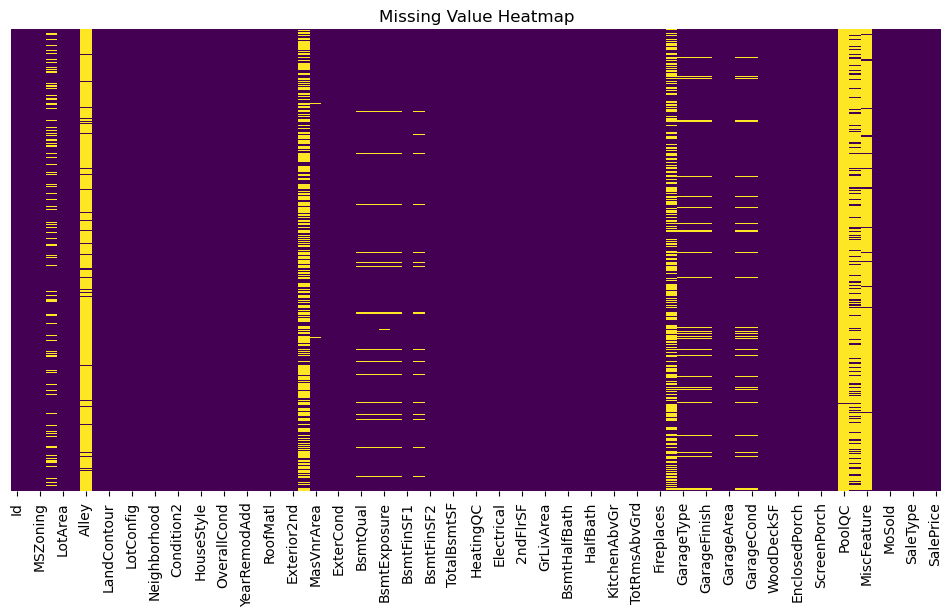

In [4]:
# Calculate missing values count and percentage
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct}).sort_values(by='Percentage (%)', ascending=False)
display(missing_df)

# Visualizing missing data
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

### Missing Data Categorization
- **High (>40% missing):** `PoolQC` (99.52%), `MiscFeature` (96.30%), `Alley` (93.77%), `Fence` (80.75%).
- **Moderate (5% - 40% missing):** `FireplaceQu` (47.26%), `LotFrontage` (17.74%), `GarageCond`, `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual` (~5.5%), `BsmtExposure`, `BsmtFinType2`, `BsmtFinType1`, `BsmtCond`, `BsmtQual` (~2.5%).
- **Low (<5% missing):** `MasVnrType` (0.55%), `MasVnrArea` (0.55%), `Electrical` (0.07%).

## 2.2 Understanding the Missingness

In [5]:
# Investigate LotFrontage median grouped by Neighborhood
lot_frontage_by_neigh = df.groupby('Neighborhood')['LotFrontage'].median()
display(lot_frontage_by_neigh)

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    74.0
Edwards    65.5
Gilbert    65.0
IDOTRR     60.0
MeadowV    21.0
Mitchel    73.0
NAmes      73.0
NPkVill    24.0
NWAmes     80.0
NoRidge    91.0
NridgHt    88.5
OldTown    60.0
SWISU      60.0
Sawyer     71.0
SawyerW    66.5
Somerst    73.5
StoneBr    61.5
Timber     85.0
Veenker    68.0
Name: LotFrontage, dtype: float64

### Missingness Mechanism Justifications
1. **Structural NA (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`):** These values are not truly "missing"; they represent the absence of that feature in the property (e.g., no pool or no alley access).
2. **`LotFrontage` (MAR - Missing at Random):** Missingness correlates with `Neighborhood` layout (e.g., cul-de-sacs or urban vs. rural developments), making it dependent on observed data.
3. **`Electrical` (MCAR - Missing Completely at Random):** Only 1 value is missing across 1,460 rows due to random collection error, completely independent of all features.

## 2.3 Imputation Strategies

In [6]:
# 1. Fill non-applicable structural features with 'None'
na_none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df[na_none_cols] = df[na_none_cols].fillna('None')

# 2. Impute LotFrontage using Neighborhood median
print("LotFrontage missing before:", df['LotFrontage'].isnull().sum())
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
print("LotFrontage missing after:", df['LotFrontage'].isnull().sum())

# 3. Impute GarageYrBlt with YearBuilt
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

# 4. SimpleImputer with mean strategy for MasVnrArea
imputer = SimpleImputer(strategy='mean')
df[['MasVnrArea']] = imputer.fit_transform(df[['MasVnrArea']])

# Fill remaining minor categorical attributes with mode
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# 5. Verify zero remaining missing values
print("Total remaining missing values:", df.isnull().sum().sum())

LotFrontage missing before: 259
LotFrontage missing after: 0
Total remaining missing values: 0


# Question 3: Outlier Detection and Treatment

## 3.1 Visual Outlier Detection

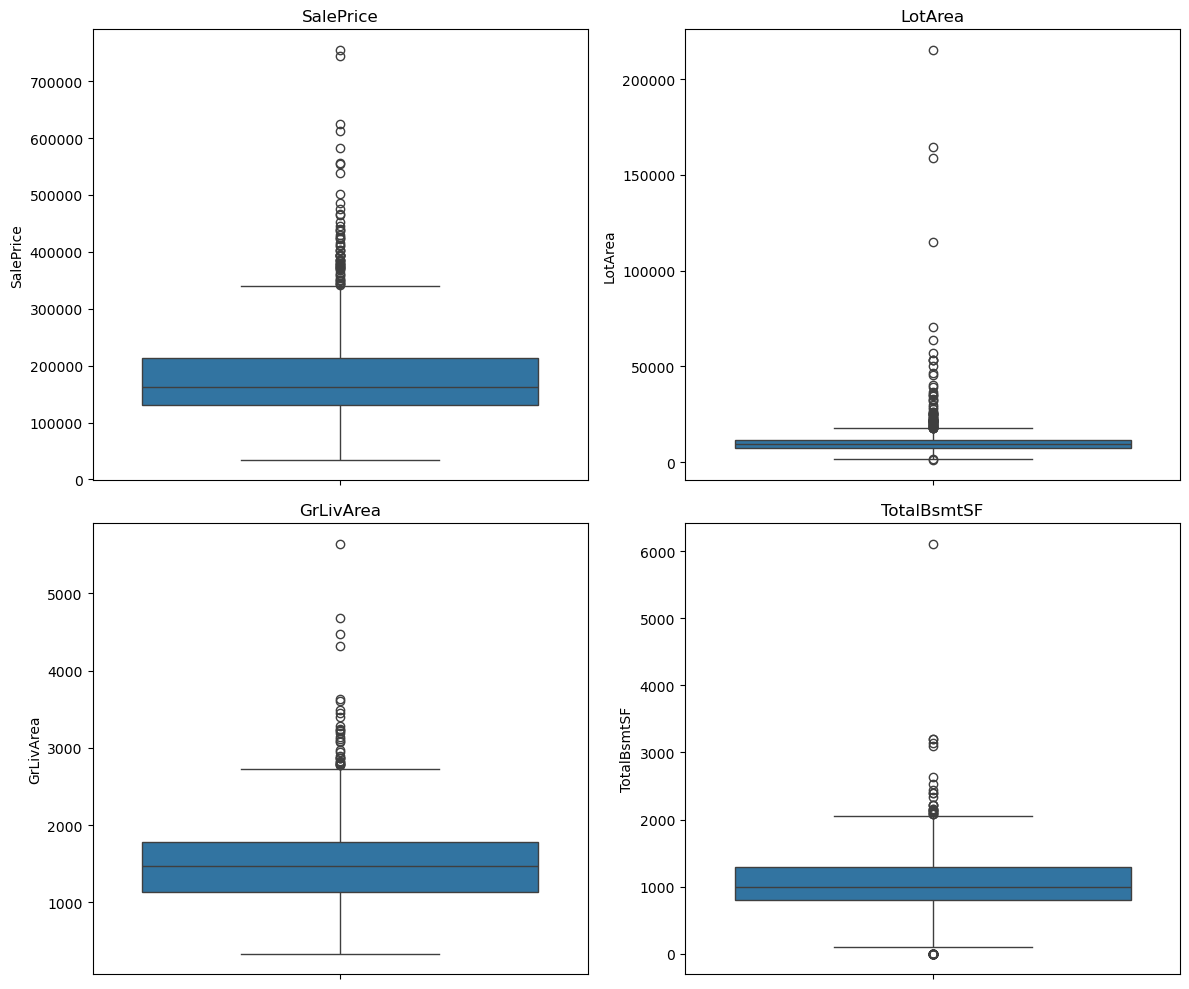

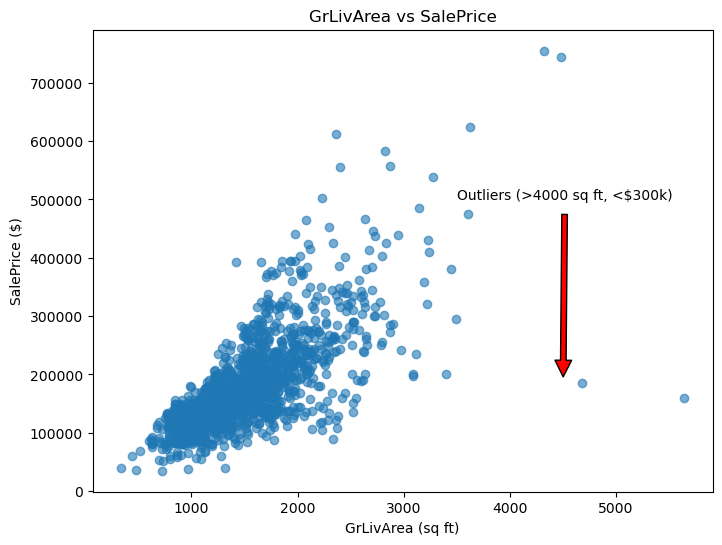

In [7]:
# 1. 2x2 Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(y=df['SalePrice'], ax=axes[0, 0]).set_title('SalePrice')
sns.boxplot(y=df['LotArea'], ax=axes[0, 1]).set_title('LotArea')
sns.boxplot(y=df['GrLivArea'], ax=axes[1, 0]).set_title('GrLivArea')
sns.boxplot(y=df['TotalBsmtSF'], ax=axes[1, 1]).set_title('TotalBsmtSF')
plt.tight_layout()
plt.show()

# 2. Scatter Plot GrLivArea vs SalePrice with Annotation
plt.figure(figsize=(8, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.6)
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice ($)')
plt.title('GrLivArea vs SalePrice')
plt.annotate('Outliers (>4000 sq ft, <$300k)', xy=(4500, 180000), xytext=(3500, 500000),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.show()

## 3.2 Statistical Outlier Detection

In [8]:
# 1. Z-Score Method
sp_z = np.abs(stats.zscore(df['SalePrice']))
gr_z = np.abs(stats.zscore(df['GrLivArea']))
z_outliers = df[(sp_z > 3) | (gr_z > 3)]
print("Z-Score detected outliers count:", len(z_outliers))

# 2. IQR Method for LotArea
Q1 = df['LotArea'].quantile(0.25)
Q3 = df['LotArea'].quantile(0.75)
IQR = Q3 - Q1
lower_b = Q1 - 1.5 * IQR
upper_b = Q3 + 1.5 * IQR
iqr_outliers = df[(df['LotArea'] < lower_b) | (df['LotArea'] > upper_b)]
print("IQR detected outliers count for LotArea:", len(iqr_outliers))

Z-Score detected outliers count: 31
IQR detected outliers count for LotArea: 69


### Comparison: Z-Score vs. IQR
IQR detected significantly more outliers than Z-score. Z-score relies on the mean and standard deviation, which are skewed by extreme values. IQR relies on robust quartiles (percentiles), making IQR superior and recommended for skewed real estate data.

## 3.3 Outlier Treatment

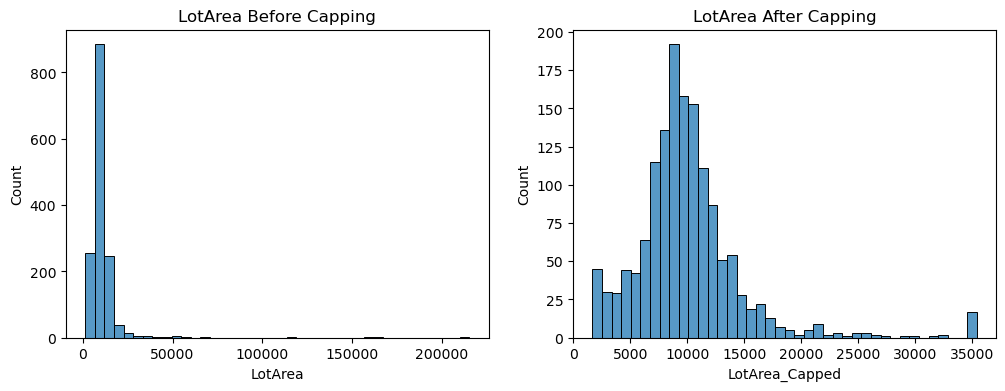

In [9]:
# 1. Remove specific GrLivArea outliers (>4000 sq ft & SalePrice < 300000)
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

# 2. Winsorization (Capping) on LotArea at 1st and 99th percentiles
p1 = df['LotArea'].quantile(0.01)
p99 = df['LotArea'].quantile(0.99)
df['LotArea_Capped'] = np.clip(df['LotArea'], p1, p99)

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['LotArea'], bins=40, ax=axes[0]).set_title('LotArea Before Capping')
sns.histplot(df['LotArea_Capped'], bins=40, ax=axes[1]).set_title('LotArea After Capping')
plt.show()

### Outlier Removal vs. Capping Considerations
1. **Data Authenticity:** Removal is appropriate when outliers represent corrupt data or extreme edge-cases that degrade model generalization.
2. **Information Retention:** Winsorization/Capping is preferred when extreme values are valid data points, preventing sample loss while mitigating disproportionate weight during model fitting.

# Question 4: Feature Engineering

## 4.1 Creating New Features

In [10]:
# 1. TotalSF
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. TotalBathrooms
df['TotalBathrooms'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])

# 3. HouseAge
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# 4. IsRemodeled
df['IsRemodeled'] = np.where(df['YearRemodAdd'] != df['YearBuilt'], 1, 0)

# 5. TotalPorchSF
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']

display(df[['TotalSF', 'TotalBathrooms', 'HouseAge', 'IsRemodeled', 'TotalPorchSF']].head())

,TotalSF,TotalBathrooms,HouseAge,IsRemodeled,TotalPorchSF
0,2566,3.5,5,0,61
1,2524,2.5,31,0,0
2,2706,3.5,7,1,42
3,2473,2.0,91,1,307
4,3343,3.5,8,0,84


## 4.2 Encoding Categorical Variables

In [11]:
# 1. Identify categorical columns count
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns count:", len(cat_cols))

# 2. Custom Label Encoding for Ordinal Columns
qual_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'None': 0}
ordinal_cols = ['ExterQual', 'BsmtQual', 'KitchenQual']
for col in ordinal_cols:
    df[col] = df[col].map(qual_map)

# 3. One-Hot Encoding for Nominal Columns
df = pd.get_dummies(df, columns=['Neighborhood', 'HouseStyle'], drop_first=True)

Categorical columns count: 45


### Label Encoding vs. One-Hot Encoding
- **Label Encoding:** Preserves inherent mathematical order ($1 < 2 < 3$) and is suitable for ordinal variables like quality metrics.
- **One-Hot Encoding:** Creates dummy binary columns for nominal variables without rank, preventing algorithms from assuming artificial hierarchy between distinct categories.

## 4.3 Feature Scaling

In [12]:
# 1. Display original ranges
scale_cols = ['LotArea_Capped', 'GrLivArea', 'TotalSF', 'HouseAge', 'TotalBathrooms']
print("Original Ranges:")
display(df[scale_cols].agg(['min', 'max']))

# 2. Min-Max Scaling
mms = MinMaxScaler()
df_mms = pd.DataFrame(mms.fit_transform(df[scale_cols]), columns=scale_cols)
print("\nMin-Max Scaled Ranges:")
display(df_mms.agg(['min', 'max']))

# 3. Standard Scaling
std = StandardScaler()
df_std = pd.DataFrame(std.fit_transform(df[scale_cols]), columns=scale_cols)
print("\nStandard Scaled Mean and Standard Deviation:")
display(df_std.agg(['mean', 'std']).round(2))

Original Ranges:


,LotArea_Capped,GrLivArea,TotalSF,HouseAge,TotalBathrooms
min,1680.00,334,334,0,1.0
max,35402.61,4476,6872,136,6.0



Min-Max Scaled Ranges:


,LotArea_Capped,GrLivArea,TotalSF,HouseAge,TotalBathrooms
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0



Standard Scaled Mean and Standard Deviation:


,LotArea_Capped,GrLivArea,TotalSF,HouseAge,TotalBathrooms
mean,-0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0


### Min-Max vs. Standard Scaling Application
- **Min-Max Scaling:** Bounds data into $[0, 1]$. Recommended for algorithms requiring normalized ranges without assumed distributions (e.g., KNN, Neural Networks).
- **Standard Scaling:** Transforms data to mean $= 0$ and standard deviation $= 1$. Recommended for linear models, logistic regression, and PCA that assume normally distributed features.

# Question 5: Data Visualization and Correlation Analysis

## 5.1 Distribution Analysis

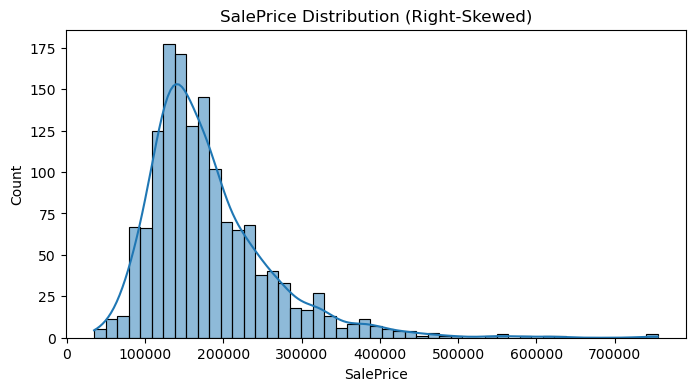

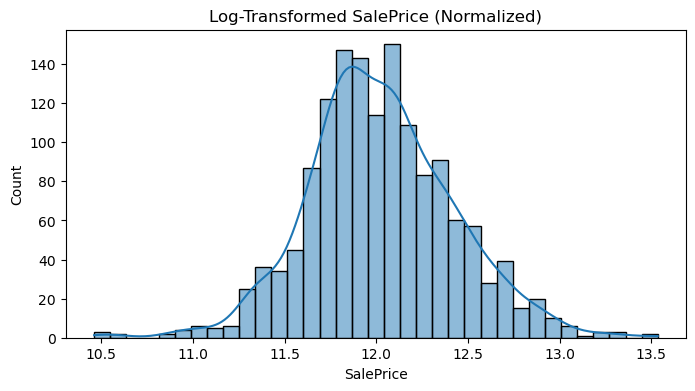

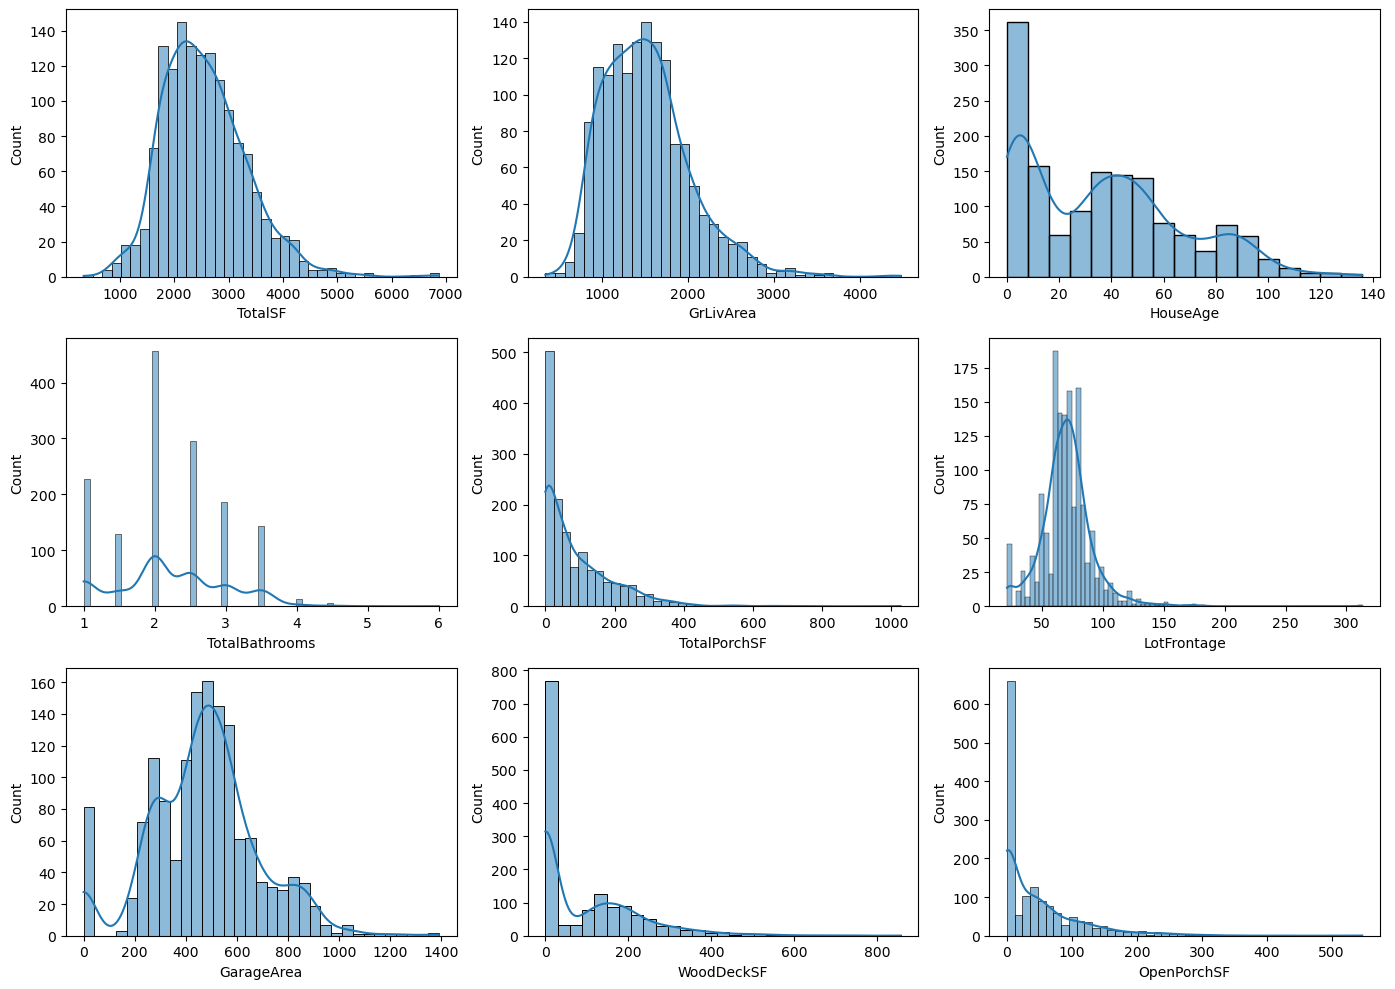

In [13]:
# 1. Original SalePrice Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], kde=True)
plt.title('SalePrice Distribution (Right-Skewed)')
plt.show()

# 2. Log-Transformed SalePrice
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df['SalePrice']), kde=True)
plt.title('Log-Transformed SalePrice (Normalized)')
plt.show()

# 3. 3x3 Histogram Grid
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
features_grid = ['TotalSF', 'GrLivArea', 'HouseAge', 'TotalBathrooms', 'TotalPorchSF', 'LotFrontage', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF']
for i, feat in enumerate(features_grid):
    sns.histplot(df[feat], kde=True, ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

## 5.2 Relationship Exploration

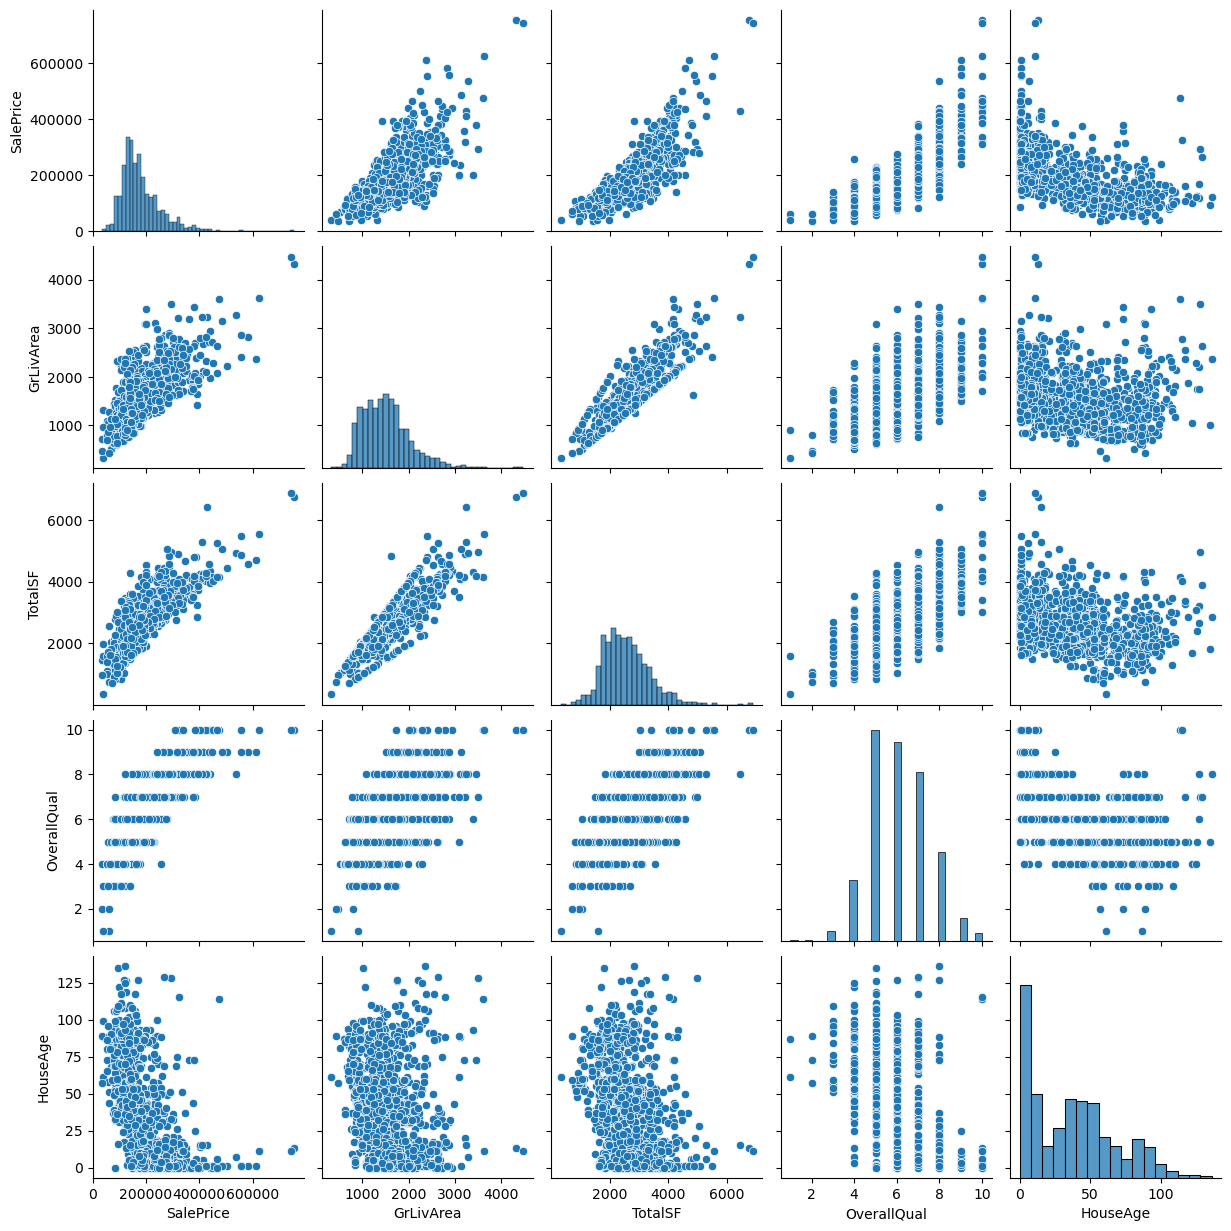

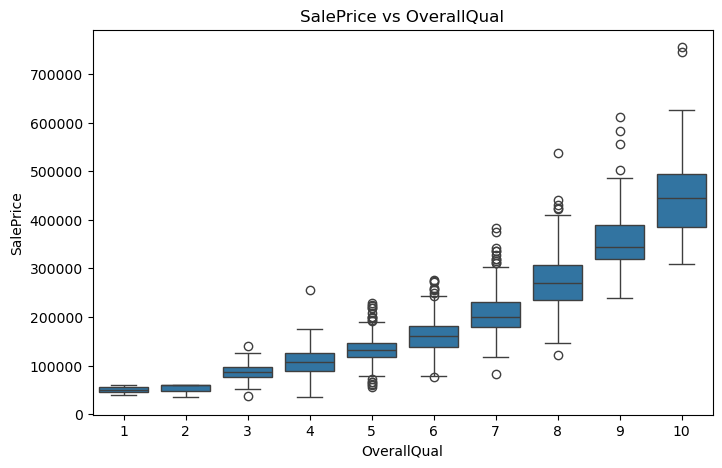

In [14]:
# 1. Pairplot
sns.pairplot(df[['SalePrice', 'GrLivArea', 'TotalSF', 'OverallQual', 'HouseAge']])
plt.show()

# 2. Boxplot: SalePrice by OverallQual
plt.figure(figsize=(8, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('SalePrice vs OverallQual')
plt.show()

### Trend Analysis (SalePrice vs OverallQual)
A non-linear, exponential increase in `SalePrice` is observed as `OverallQual` increases from 1 to 10. Higher quality homes show higher medians and larger interquartile variance.

## 5.3 Correlation Analysis

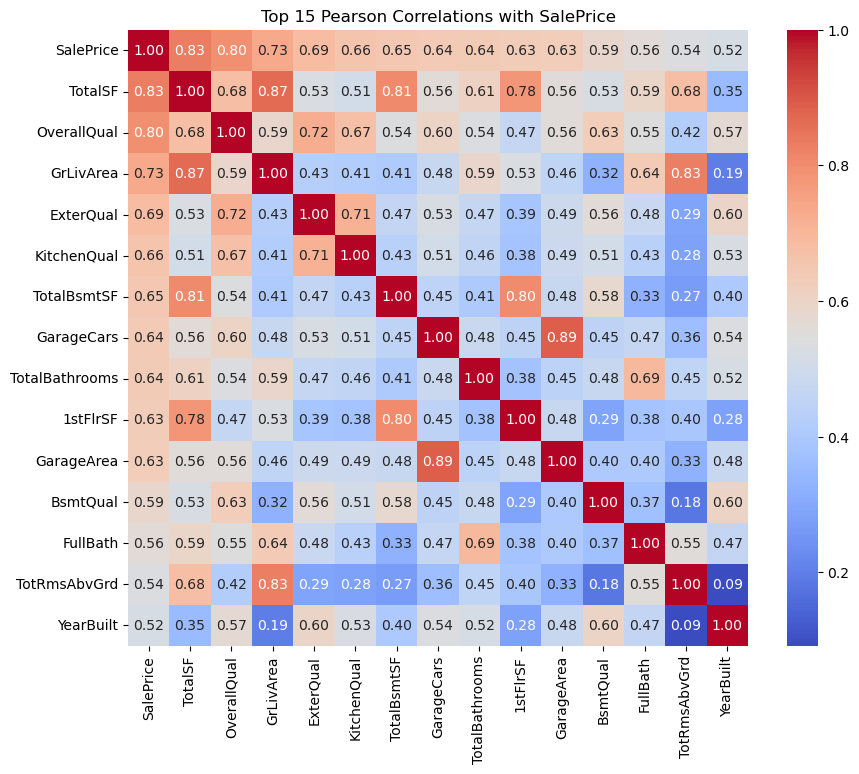

Top 10 Positive and Top 5 Negative Correlations:


,Feature,Correlation with SalePrice
0,TotalSF,0.832877
1,OverallQual,0.795774
2,GrLivArea,0.734968
3,ExterQual,0.686756
4,KitchenQual,0.662236
5,TotalBsmtSF,0.651153
6,GarageCars,0.641047
7,TotalBathrooms,0.635896
8,1stFlrSF,0.631530
9,GarageArea,0.629217


Pearson Correlation: 0.7958
Spearman Rank Correlation: 0.8111


In [16]:
# 1 & 2. Heatmap of top 15 features correlated with SalePrice
num_df = df.select_dtypes(include=[np.number])
top_15_cols = num_df.corr().nlargest(15, 'SalePrice')['SalePrice'].index
plt.figure(figsize=(10, 8))
sns.heatmap(num_df[top_15_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Top 15 Pearson Correlations with SalePrice")
plt.show()

# 3. Top 10 Positive and Top 5 Negative Correlated Features
corr_series = num_df.corr()['SalePrice'].sort_values(ascending=False)

# Extract top 10 positive (skipping index 0, which is SalePrice itself) and top 5 negative
top_10_pos = corr_series.iloc[1:11]
top_5_neg = corr_series.iloc[-5:]

# Combine them vertically and format as a DataFrame
combined_corr = pd.concat([top_10_pos, top_5_neg])
corr_table = pd.DataFrame(combined_corr).reset_index()
corr_table.columns = ['Feature', 'Correlation with SalePrice']

print("Top 10 Positive and Top 5 Negative Correlations:")
display(corr_table)

# 5. Spearman vs Pearson for OverallQual
p_corr = num_df['OverallQual'].corr(num_df['SalePrice'], method='pearson')
s_corr = num_df['OverallQual'].corr(num_df['SalePrice'], method='spearman')
print(f"Pearson Correlation: {p_corr:.4f}")
print(f"Spearman Rank Correlation: {s_corr:.4f}")

### Multicollinearity & Correlation Analysis
- **Multicollinearity:** Features like `GarageCars` and `GarageArea` ($r > 0.8$) or `TotalSF` and `GrLivArea` show strong linear dependency. In linear models, multicollinearity inflates standard errors and makes coefficient estimates unstable.
- **Pearson vs. Spearman:** Spearman correlation evaluates monotonic rank ordering, while Pearson measures strict linear fit. Because the relationship between `OverallQual` and `SalePrice` is monotonic exponential rather than strictly linear, Spearman gives a higher correlation coefficient.